In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from statsmodels.stats.proportion import proportions_ztest
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("df_reduced_extended.csv")

print("Shape:", df.shape)
print(df.head())


FileNotFoundError: [Errno 2] No such file or directory: 'df_reduced_extended.csv'

In [89]:
df.describe()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,month,treatment_cost,frequency,recency_days,monetary,past_visit_rate,past_conversion_rate,is_evening,is_weekend,engagement_score
count,96364.000000,96364.000000,96364.000000,96364.000000,96364.000000,96364.000000,96364.000000,96364.000000,96364.000000,96364.000000,...,96364.000000,96364.000000,96364.000000,96364.000000,96364.000000,96364.000000,96364.000000,96364.000000,96364.000000,96364.000000
mean,19.021831,10.080571,8.438176,3.944439,10.416880,3.977452,-4.694293,5.196186,3.911493,18.992738,...,6.484268,0.272315,2.996918,59.467654,33.038377,0.249743,0.034184,0.359159,0.285387,0.296904
std,5.339883,0.156746,0.282098,1.653609,0.557886,0.575946,5.132041,1.370204,0.073566,10.137157,...,3.448184,0.558322,1.729770,60.328170,42.808958,0.144147,0.042817,0.479756,0.451601,0.137713
min,12.616365,10.059654,8.214383,-6.635847,10.280525,-5.913968,-26.676356,4.833815,3.635107,13.190056,...,1.000000,0.000000,0.000000,0.000000,0.410000,0.000000,0.000426,0.000000,0.000000,0.000000
25%,12.616365,10.059654,8.214383,4.679882,10.280525,4.115453,-7.822229,4.833815,3.859290,13.190056,...,3.000000,0.010000,2.000000,17.000000,10.180000,0.166667,0.010569,0.000000,0.000000,0.173293
50%,20.210277,10.059654,8.277523,4.679882,10.280525,4.115453,-3.282109,4.833815,3.943716,13.190056,...,6.000000,0.020000,3.000000,41.000000,20.045000,0.250000,0.020811,0.000000,0.000000,0.287335
75%,24.079022,10.059654,8.666123,4.679882,10.280525,4.115453,0.294443,4.833815,3.971858,21.416100,...,9.000000,0.050000,4.000000,82.000000,39.550000,0.333333,0.041061,1.000000,1.000000,0.406971
max,26.745199,15.098192,9.051958,4.679882,20.278040,4.115453,0.294443,11.998383,3.971858,75.295017,...,12.000000,1.500000,11.000000,718.000000,962.190000,0.916667,0.500000,1.000000,1.000000,1.000000


## EDA

In [3]:
print("Total rows:", len(df))
print(df.info())
print(df.head())

NameError: name 'df' is not defined

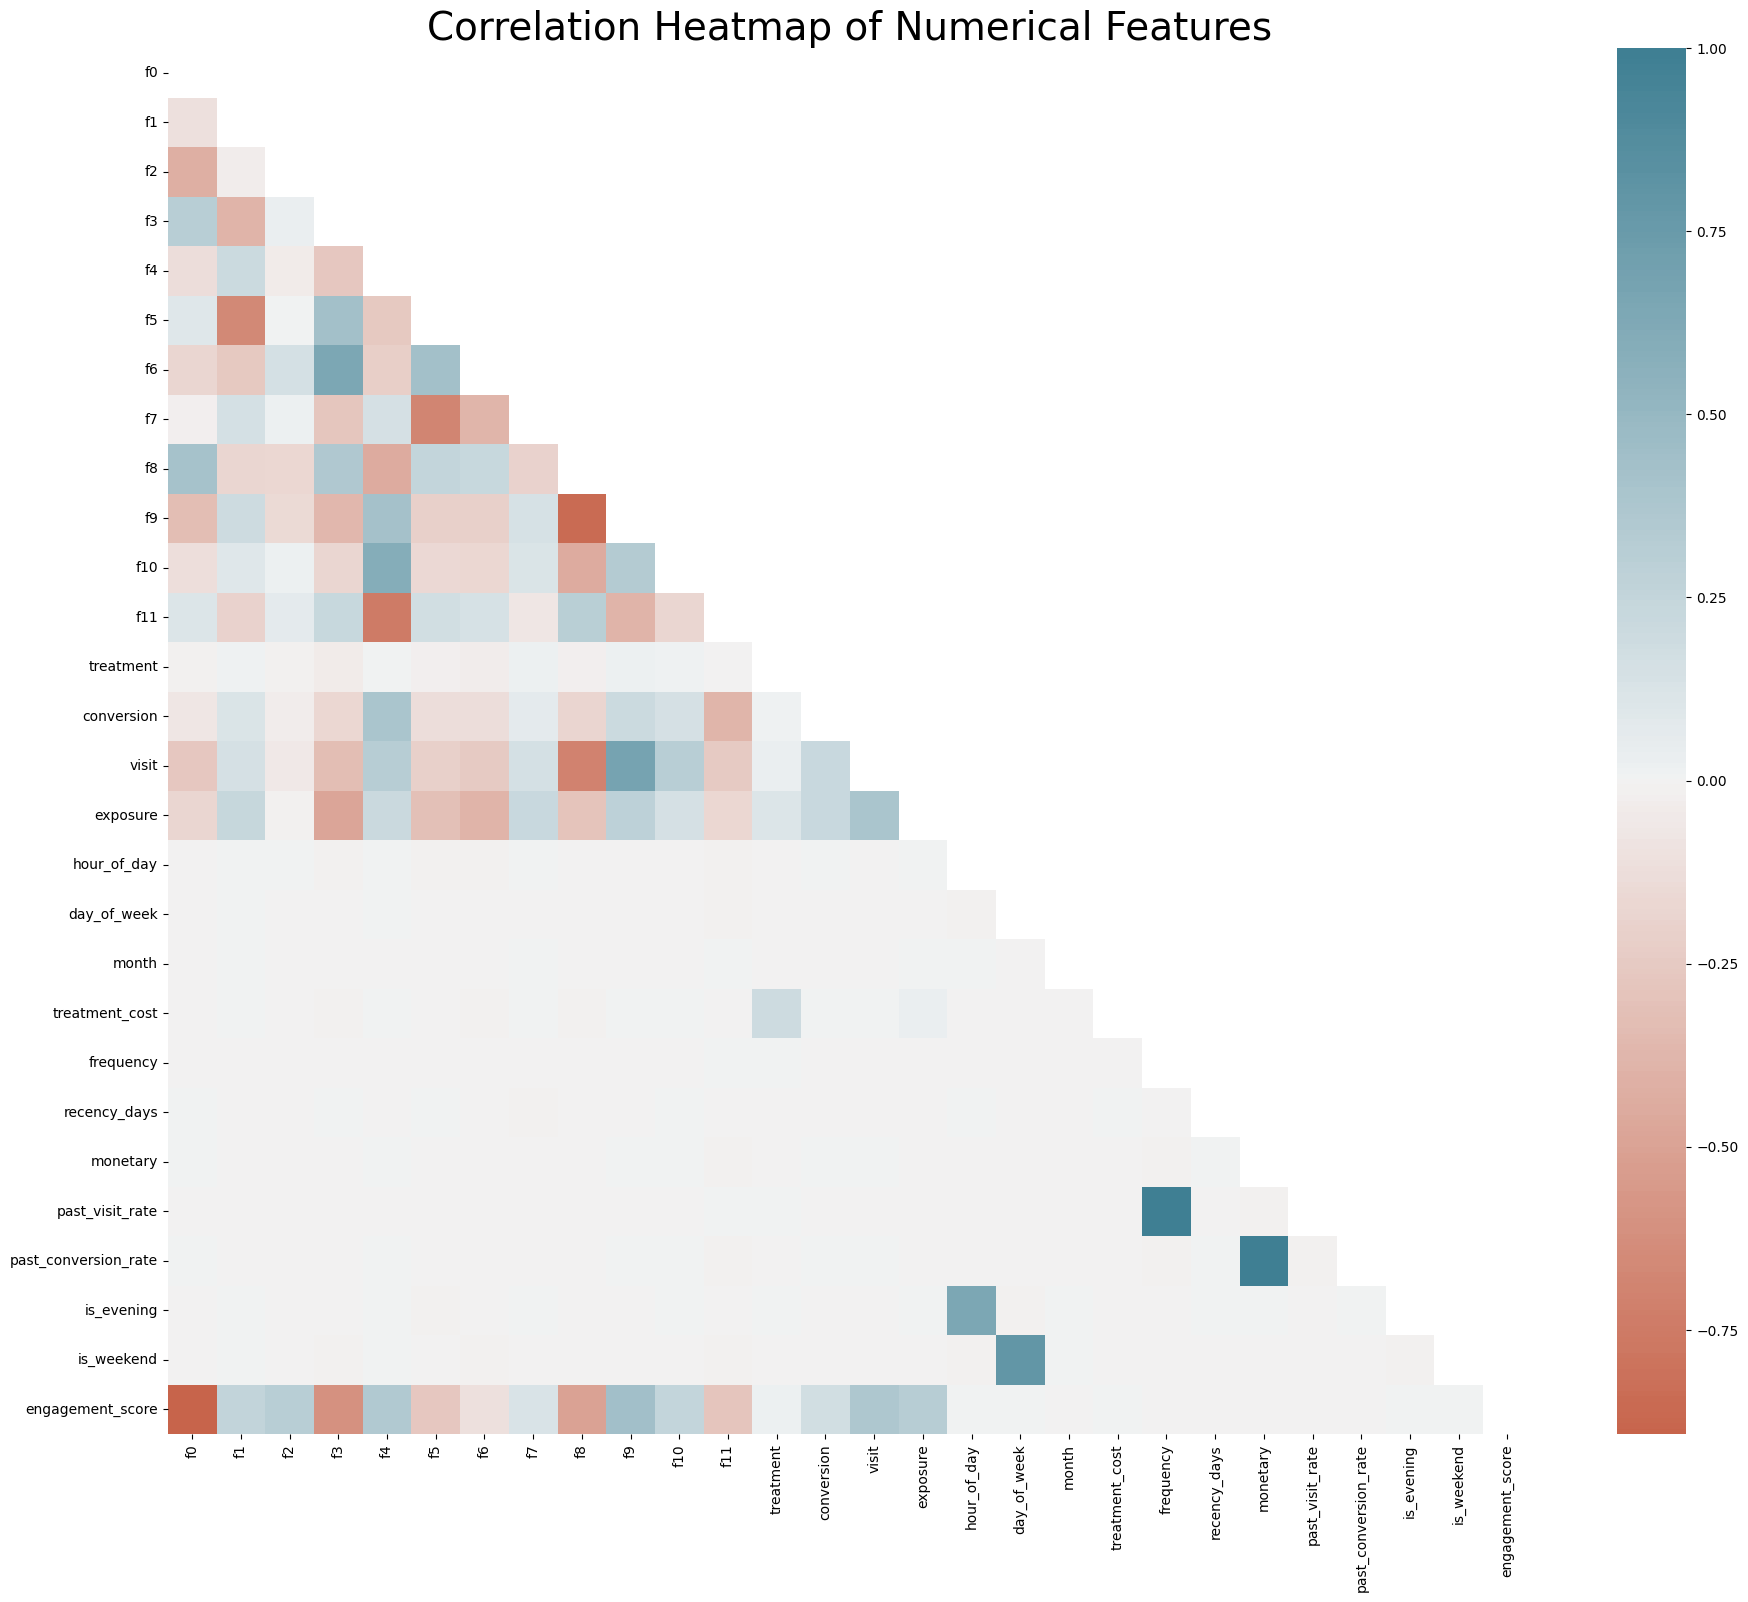

In [ ]:
plt.figure(figsize=(22,18))

corr = df.select_dtypes(include=[np.number]).corr()

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr,
    mask=mask,
    cmap=sns.diverging_palette(20, 220, n=220),
    annot=False,
    center=0
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=28)
plt.show()

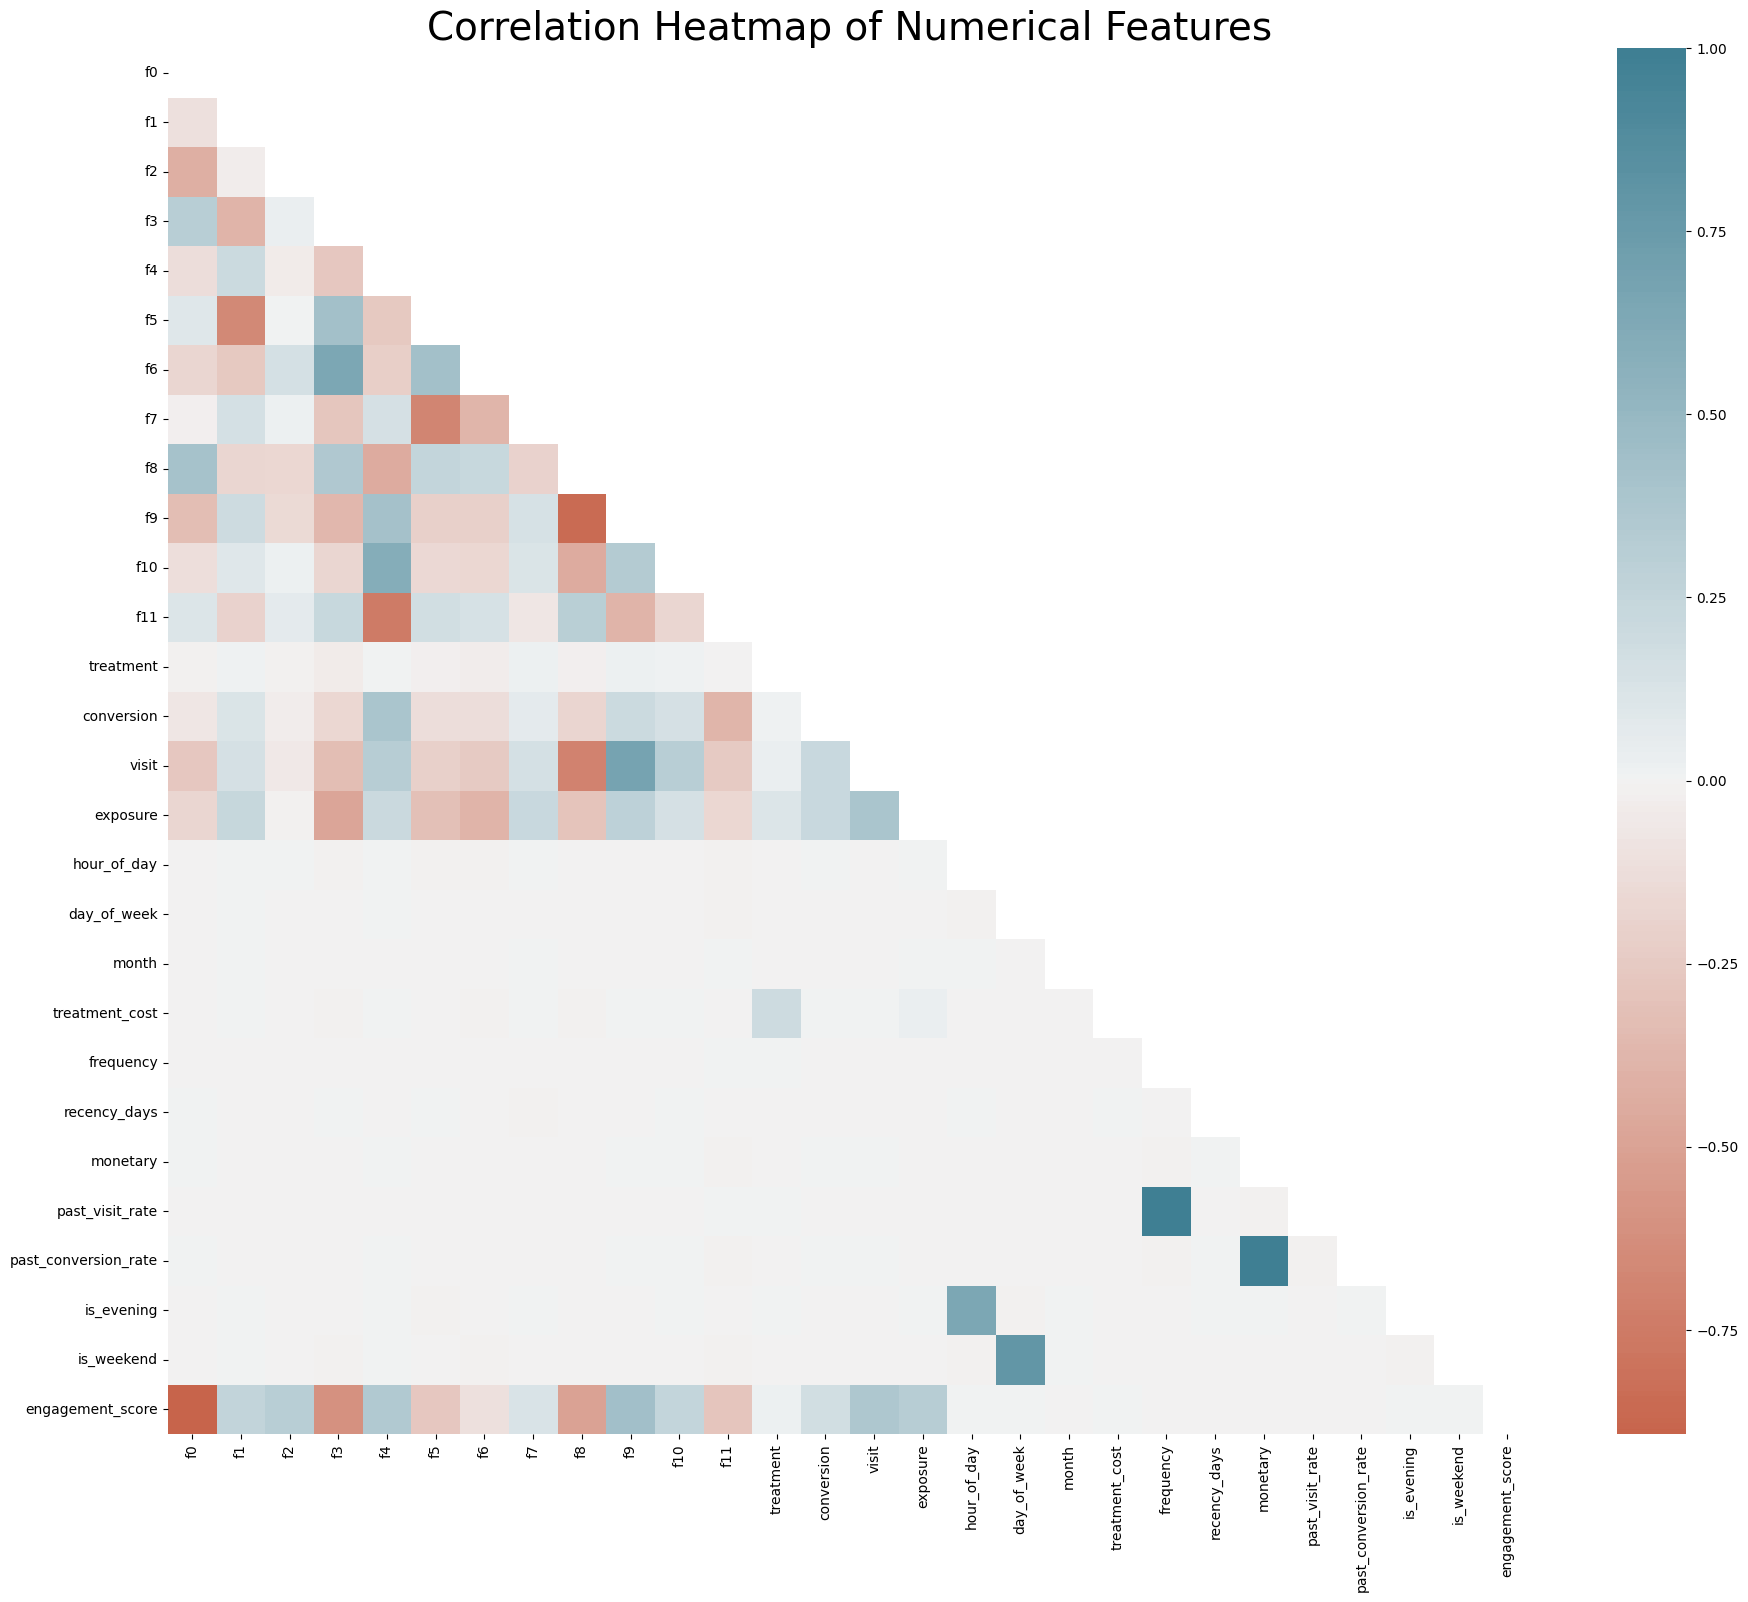

In [ ]:
plt.figure(figsize=(22,18))

corr = df.select_dtypes(include=[np.number]).corr()

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr,
    mask=mask,
    cmap=sns.diverging_palette(20, 220, n=220),
    annot=False,
    center=0
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=28)
plt.show()

In [ ]:
vis_results_df = df.groupby('treatment').agg({'visit':['mean','sum','count']})
print("\nVisit stats (control vs treatment):\n", vis_results_df)

con_results_df = df.groupby('treatment').agg({'conversion':['mean','sum','count']})
print("\nConversion stats (control vs treatment):\n", con_results_df)

print("\nDifference in visit rate:",
      np.round(df.groupby("treatment")["visit"].mean()[1] - df.groupby("treatment")["visit"].mean()[0], 4))

print("Difference in conversion rate:",
      np.round(df.groupby("treatment")["conversion"].mean()[1] - df.groupby("treatment")["conversion"].mean()[0], 4))



Visit stats (control vs treatment):
               visit              
               mean    sum  count
treatment                        
0          0.192233   2668  13879
1          0.233170  19233  82485

Conversion stats (control vs treatment):
           conversion             
                mean   sum  count
treatment                        
0           0.010231   142  13879
1           0.014827  1223  82485

Difference in visit rate: 0.0409
Difference in conversion rate: 0.0046


In [ ]:
print("\nVisit Z-test p-value:",
      proportions_ztest(count=vis_results_df[('visit','sum')],
                        nobs=vis_results_df[('visit','count')])[1])

print("Conversion Z-test p-value:",
      proportions_ztest(count=con_results_df[('conversion','sum')],
                        nobs=con_results_df[('conversion','count')])[1])



Visit Z-test p-value: 1.7967915113109597e-26
Conversion Z-test p-value: 2.246933169192503e-05



Visit rate per treatment type:
treatment_type
discount          0.233430
email             0.232384
none              0.192233
push              0.233459
recommendation    0.234447
Name: visit, dtype: float64

Conversion rate per treatment type:
treatment_type
discount          0.014964
email             0.014486
none              0.010231
push              0.015376
recommendation    0.014638
Name: conversion, dtype: float64


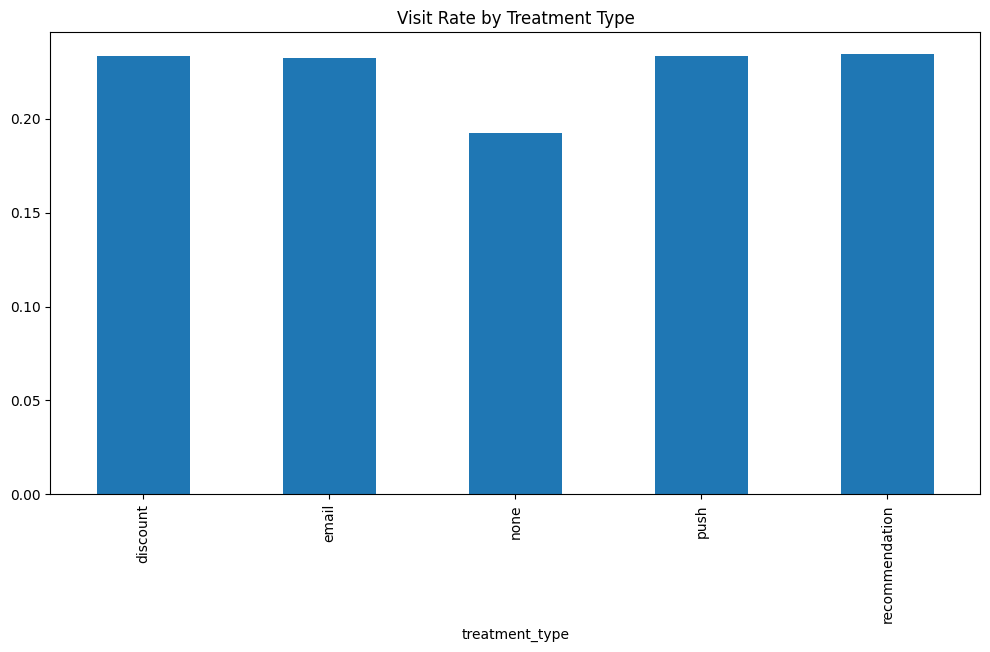

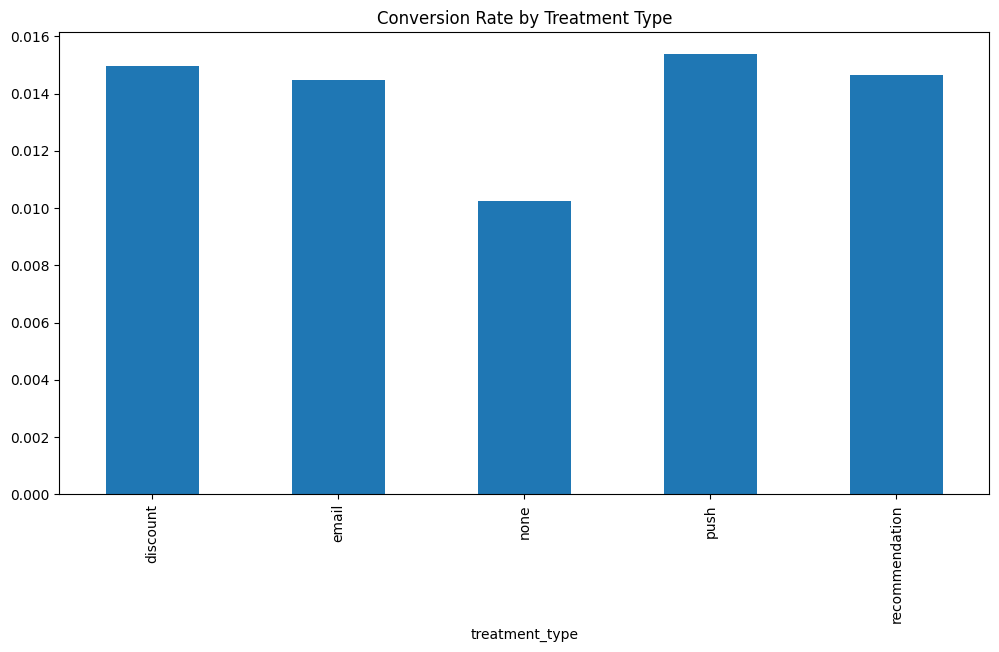

In [ ]:
print("\nVisit rate per treatment type:")
print(df.groupby('treatment_type')['visit'].mean())

print("\nConversion rate per treatment type:")
print(df.groupby('treatment_type')['conversion'].mean())

plt.figure(figsize=(12,6))
df.groupby('treatment_type')['visit'].mean().plot(kind='bar')
plt.title("Visit Rate by Treatment Type")
plt.show()

plt.figure(figsize=(12,6))
df.groupby('treatment_type')['conversion'].mean().plot(kind='bar')
plt.title("Conversion Rate by Treatment Type")
plt.show()


Visit rate per treatment type:
treatment_type
discount          0.233430
email             0.232384
none              0.192233
push              0.233459
recommendation    0.234447
Name: visit, dtype: float64

Conversion rate per treatment type:
treatment_type
discount          0.014964
email             0.014486
none              0.010231
push              0.015376
recommendation    0.014638
Name: conversion, dtype: float64


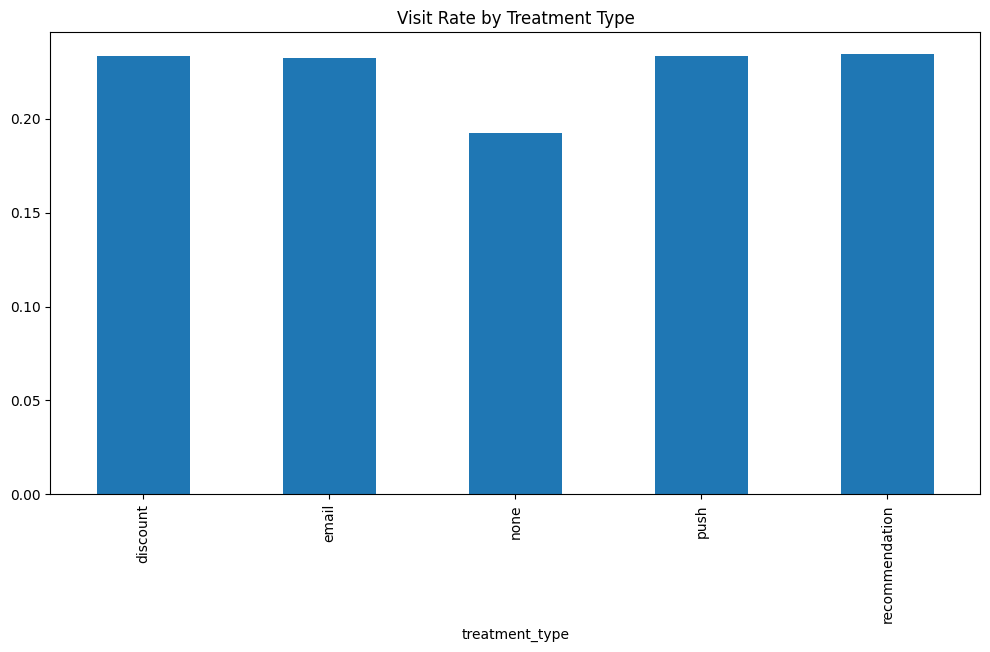

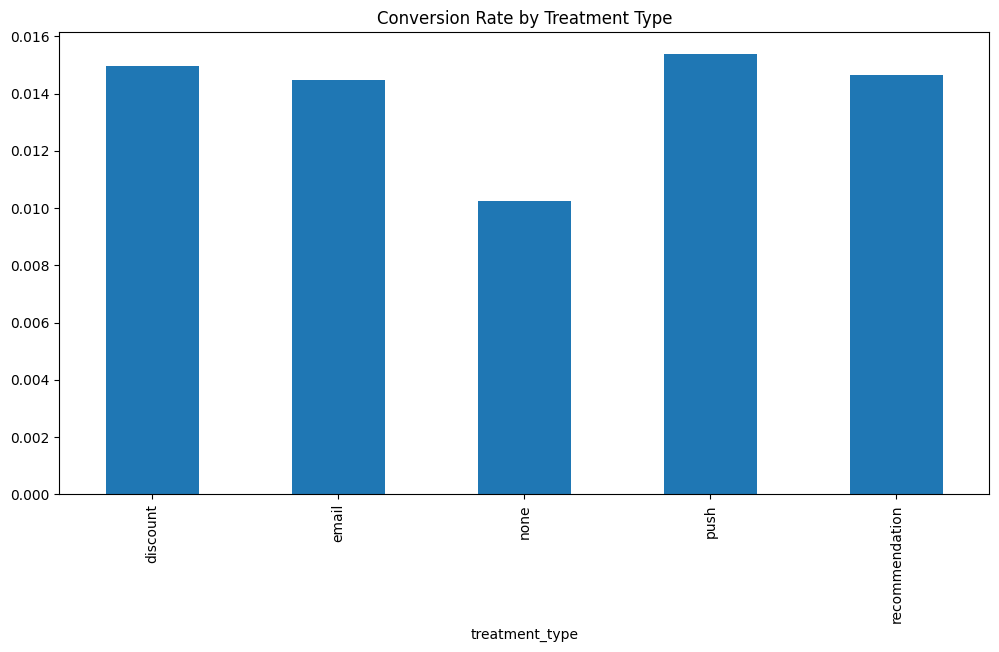

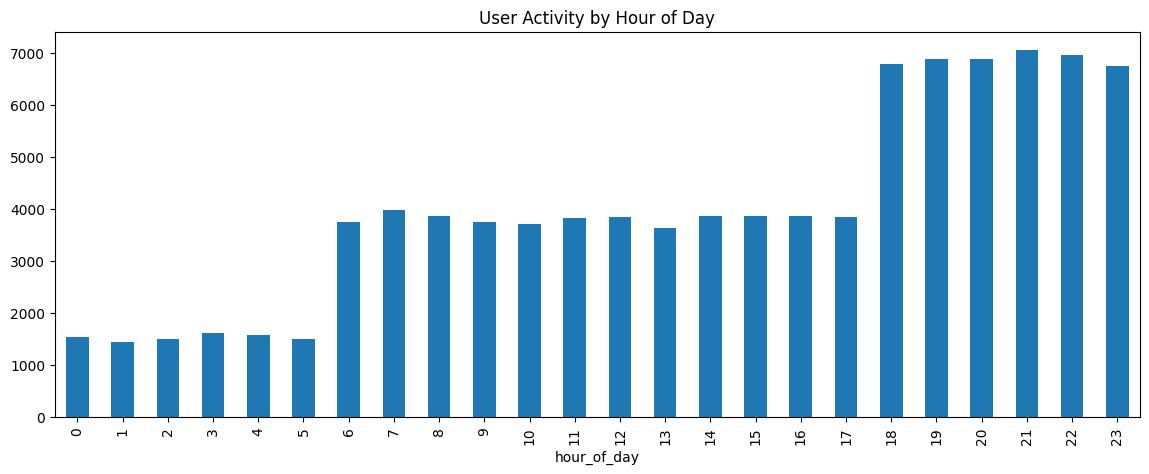

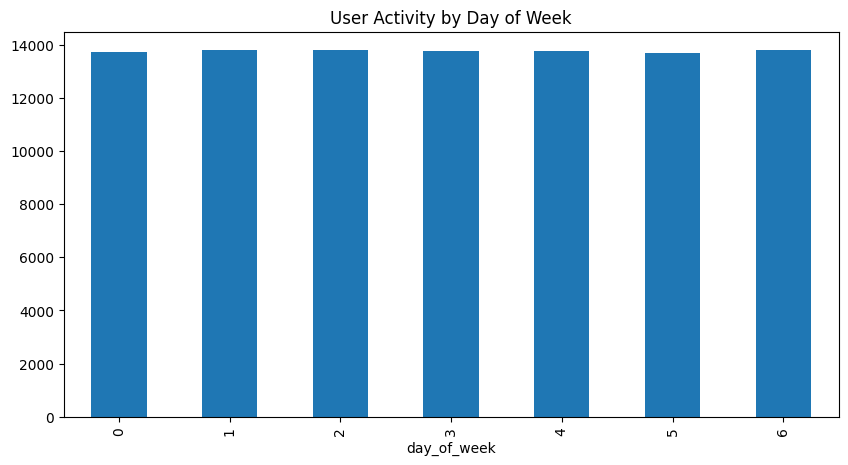

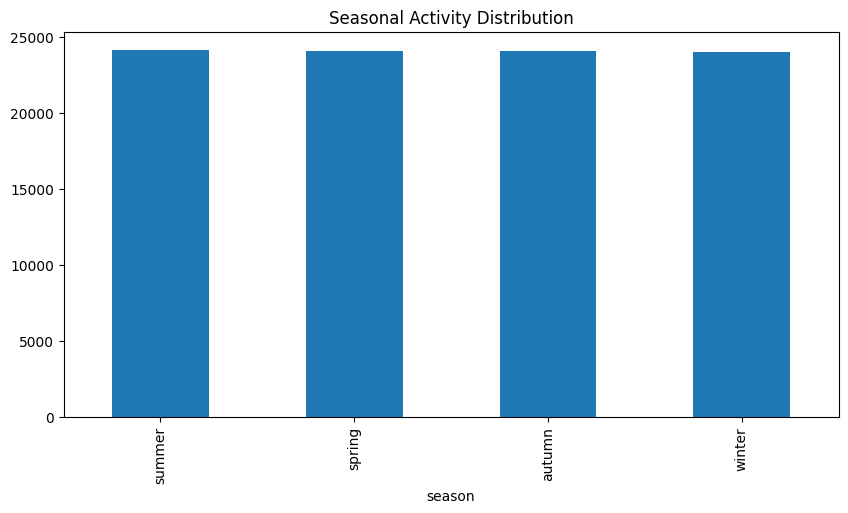


Visit rate by hour:
hour_of_day
0     0.2243
1     0.2321
2     0.2208
3     0.2079
4     0.2298
5     0.2268
6     0.2238
7     0.2417
8     0.2083
9     0.2307
10    0.2252
11    0.2402
12    0.2245
13    0.2317
14    0.2206
15    0.2262
16    0.2335
17    0.2318
18    0.2372
19    0.2236
20    0.2308
21    0.2302
22    0.2185
23    0.2224
Name: visit, dtype: float64

Conversion rate by hour:
hour_of_day
0     0.0105
1     0.0160
2     0.0093
3     0.0081
4     0.0165
5     0.0126
6     0.0139
7     0.0110
8     0.0166
9     0.0141
10    0.0164
11    0.0128
12    0.0146
13    0.0146
14    0.0142
15    0.0134
16    0.0155
17    0.0132
18    0.0147
19    0.0160
20    0.0142
21    0.0139
22    0.0128
23    0.0161
Name: conversion, dtype: float64


In [ ]:
print("\nVisit rate per treatment type:")
print(df.groupby('treatment_type')['visit'].mean())

print("\nConversion rate per treatment type:")
print(df.groupby('treatment_type')['conversion'].mean())

plt.figure(figsize=(12,6))
df.groupby('treatment_type')['visit'].mean().plot(kind='bar')
plt.title("Visit Rate by Treatment Type")
plt.show()

plt.figure(figsize=(12,6))
df.groupby('treatment_type')['conversion'].mean().plot(kind='bar')
plt.title("Conversion Rate by Treatment Type")
plt.show()

plt.figure(figsize=(14,5))
df['hour_of_day'].value_counts().sort_index().plot(kind='bar')
plt.title("User Activity by Hour of Day")
plt.show()

plt.figure(figsize=(10,5))
df['day_of_week'].value_counts().sort_index().plot(kind='bar')
plt.title("User Activity by Day of Week")
plt.show()

plt.figure(figsize=(10,5))
df['season'].value_counts().plot(kind='bar')
plt.title("Seasonal Activity Distribution")
plt.show()

print("\nVisit rate by hour:")
print(df.groupby('hour_of_day')['visit'].mean().round(4))

print("\nConversion rate by hour:")
print(df.groupby('hour_of_day')['conversion'].mean().round(4))


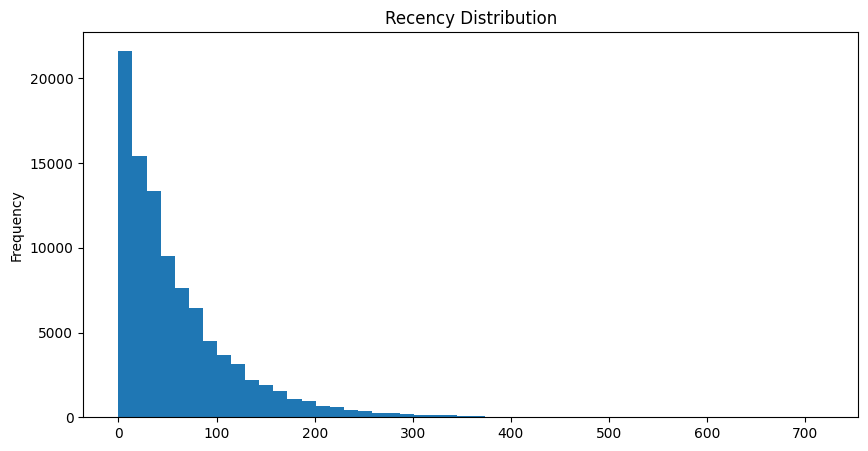

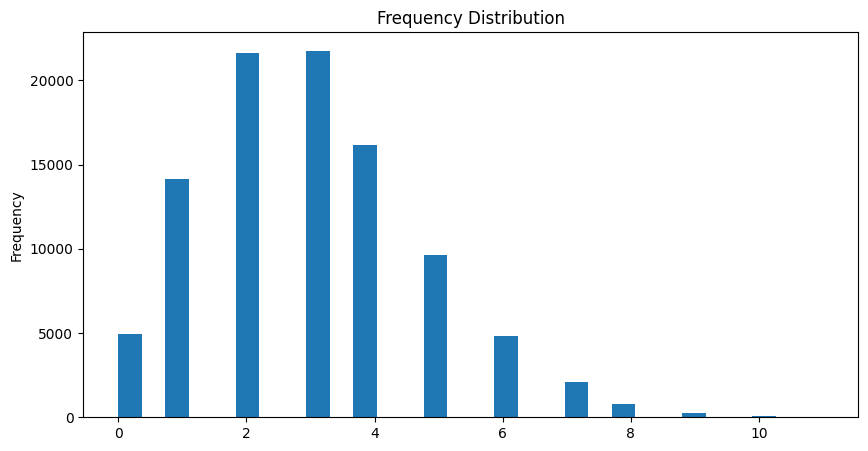

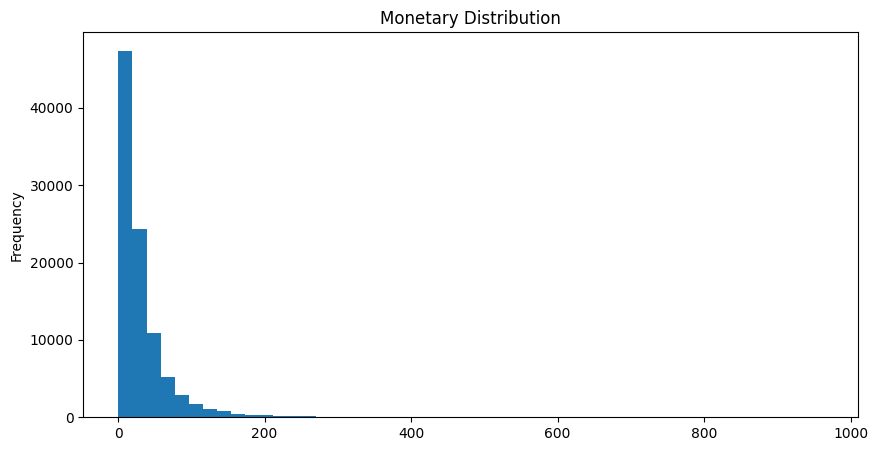


Average visit rate by RFM tiers:
frequency
(-0.001, 2.0]    0.228491
(2.0, 3.0]       0.226519
(3.0, 4.0]       0.224056
(4.0, 11.0]      0.228344
Name: visit, dtype: float64


In [ ]:
plt.figure(figsize=(10,5))
df['recency_days'].plot(kind='hist', bins=50)
plt.title("Recency Distribution")
plt.show()

plt.figure(figsize=(10,5))
df['frequency'].plot(kind='hist', bins=30)
plt.title("Frequency Distribution")
plt.show()

plt.figure(figsize=(10,5))
df['monetary'].plot(kind='hist', bins=50)
plt.title("Monetary Distribution")
plt.show()

print("\nAverage visit rate by RFM tiers:")
print(df.groupby(pd.qcut(df['frequency'], 4))['visit'].mean())


In [ ]:
print("\nVisit rate (evening vs non-evening):")
print(df.groupby('is_evening')['visit'].mean())

print("\nVisit rate (weekend vs weekday):")
print(df.groupby('is_weekend')['visit'].mean())


Visit rate (evening vs non-evening):
is_evening
0    0.226868
1    0.227998
Name: visit, dtype: float64

Visit rate (weekend vs weekday):
is_weekend
0    0.227423
1    0.226901
Name: visit, dtype: float64


### Feature Engineering + Modeling Dataset Preparation

In [ ]:
drop_cols = [
    'conversion',
    'exposure',
]

for col in drop_cols:
    if col in df.columns:
        df = df.drop(columns=[col])

In [ ]:
model_features = [
    'f0','f1','f2','f3','f4','f5','f6','f7','f8','f9','f10','f11',  
    'treatment',                                                   
    'treatment_type',                                              
    'treatment_cost',
    'hour_of_day','day_of_week','month','season',                 
    'is_evening','is_weekend',                                    
    'recency_days','frequency','monetary',                       
    'past_visit_rate','past_conversion_rate',         
    'visit'                                                       
]

df_model = df[model_features].copy()

print("Model dataframe shape:", df_model.shape)
print(df_model.head())

Model dataframe shape: (96364, 27)
          f0         f1        f2        f3         f4        f5         f6  \
0  12.616365  10.059654  8.214494  4.679882  10.280525  4.115453   0.294443   
1  24.119214  10.059654  8.214383  4.679882  10.280525  4.115453  -8.058865   
2  12.616365  10.059654  8.232055  4.679882  10.280525  4.115453   0.294443   
3  12.785162  10.059654  8.237348 -0.824913  10.280525  4.115453 -10.987528   
4  26.364530  10.059654  9.029391  4.679882  10.280525  4.115453  -3.282109   

         f7        f8         f9  ...  month  season  is_evening is_weekend  \
0  4.833815  3.934656  20.050937  ...      3  spring           0          0   
1  4.833815  3.971858  13.190056  ...     12  winter           0          1   
2  4.833815  3.833768  29.642144  ...     12  winter           0          0   
3  4.833815  3.915574  23.570168  ...      8  summer           0          1   
4  4.833815  3.878372  13.190056  ...      4  spring           1          0   

   recency_days

In [ ]:
df_model = pd.get_dummies(df_model, columns=['treatment_type', 'season'], drop_first=True)

print("\nColumns after encoding:")
print(df_model.columns.tolist())


Columns after encoding:
['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'treatment', 'treatment_cost', 'hour_of_day', 'day_of_week', 'month', 'is_evening', 'is_weekend', 'recency_days', 'frequency', 'monetary', 'past_visit_rate', 'past_conversion_rate', 'visit', 'treatment_type_email', 'treatment_type_none', 'treatment_type_push', 'treatment_type_recommendation', 'season_spring', 'season_summer', 'season_winter']


In [ ]:
def target_class(df):
    df['target_class'] = 0  # CN

    # CR
    df.loc[(df['treatment']==0) & (df['visit']==1), 'target_class'] = 1

    # TN
    df.loc[(df['treatment']==1) & (df['visit']==0), 'target_class'] = 2

    # TR
    df.loc[(df['treatment']==1) & (df['visit']==1), 'target_class'] = 3
    
    return df

df_model = target_class(df_model)
print("\nTarget class distribution:")
print(df_model['target_class'].value_counts())


Target class distribution:
target_class
2    63252
3    19233
0    11211
1     2668
Name: count, dtype: int64


In [ ]:
train, test = train_test_split(
    df_model,
    test_size=0.2,
    random_state=42,
    stratify=df_model['treatment']
)

print("\nTrain:", train.shape, " Test:", test.shape)


Train: (77091, 33)  Test: (19273, 33)


In [ ]:
def random_under(df, feature):
    counts = df[feature].value_counts()
    minority_class = counts.idxmin()
    majority_class = counts.idxmax()

    df_min = df[df[feature] == minority_class]
    df_maj = df[df[feature] == majority_class].sample(len(df_min), random_state=42)

    return pd.concat([df_min, df_maj], axis=0).sample(frac=1, random_state=42)

train_balanced = random_under(train, 'treatment')

print("\nBalanced training set shape:", train_balanced.shape)
print(train_balanced['treatment'].value_counts())


Balanced training set shape: (22206, 33)
treatment
1    11103
0    11103
Name: count, dtype: int64


In [ ]:
X_train = train_balanced.drop(columns=['visit','target_class'])
y_train = train_balanced['target_class']

X_test = test.drop(columns=['visit','target_class'])
y_test = test['target_class']

print("\nFinal shapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


Final shapes:
X_train: (22206, 31)
y_train: (22206,)
X_test: (19273, 31)
y_test: (19273,)


### Customer Segmentation

In [ ]:
segmentation_features = [
    'recency_days','frequency','monetary',
    'past_visit_rate','past_conversion_rate',
    'hour_of_day','is_evening','is_weekend',
    'f0','f1','f2','f3','f4','f5','f6','f7','f8','f9','f10','f11'
]

segmentation_features = [f for f in segmentation_features if f in df.columns]

df_seg = df[segmentation_features].copy()

print("Using segmentation features:")
print(segmentation_features)

Using segmentation features:
['recency_days', 'frequency', 'monetary', 'past_visit_rate', 'past_conversion_rate', 'hour_of_day', 'is_evening', 'is_weekend', 'f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11']


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_seg)

2
3
4
5
6
7
8


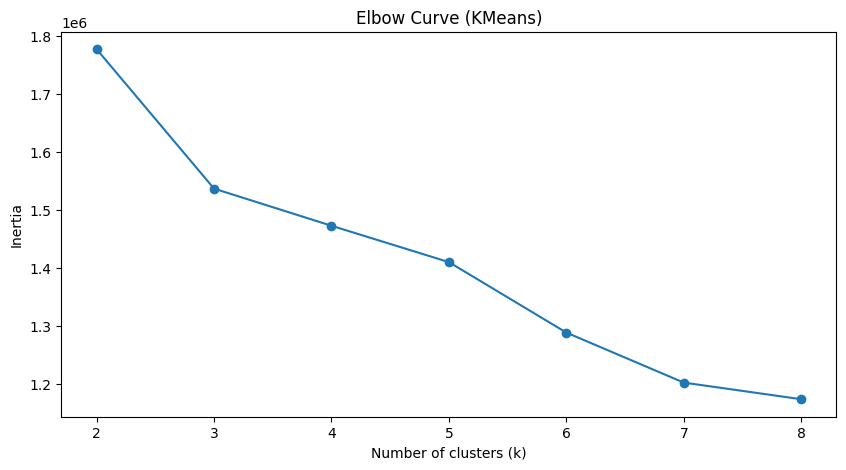

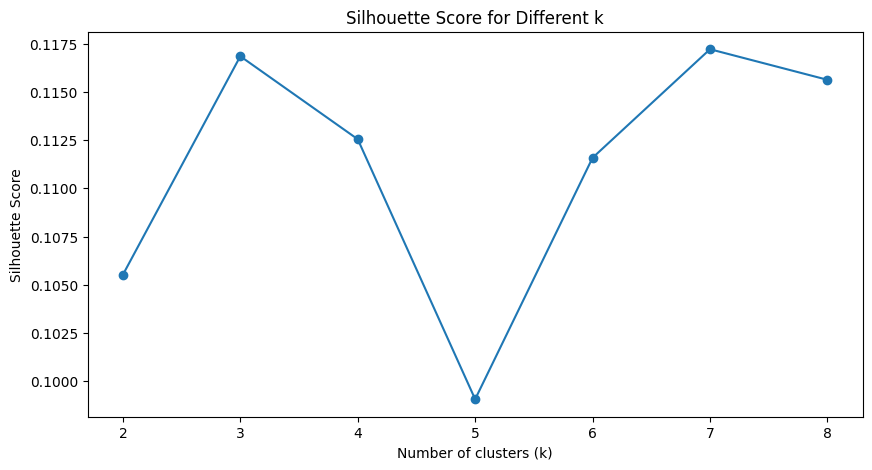

In [ ]:
inertias = []
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    print(k)

plt.figure(figsize=(10,5))
plt.plot(K_range, inertias, marker='o')
plt.title("Elbow Curve (KMeans)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(K_range, sil_scores, marker='o')
plt.title("Silhouette Score for Different k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()


In [ ]:
best_k = K_range[np.argmax(sil_scores)]
print("Best number of clusters:", best_k)

kmeans = KMeans(n_clusters=best_k, random_state=42)
df['segment_id'] = kmeans.fit_predict(X_scaled)

print("\nSegment counts:")
print(df['segment_id'].value_counts())

Best number of clusters: 7

Segment counts:
segment_id
6    26134
0    22370
4    16301
1    14717
3     6755
5     6560
2     3527
Name: count, dtype: int64


In [ ]:
segment_profile = df.groupby('segment_id')[segmentation_features + ['visit','treatment']].mean()

print("\nSegment profile (mean values):")
print(segment_profile)


Segment profile (mean values):
            recency_days  frequency    monetary  past_visit_rate  \
segment_id                                                         
0              58.894993   2.523380   26.330142         0.210282   
1              59.053611   2.741388   26.885506         0.228449   
2              60.519422   2.888574  189.289033         0.240714   
3              60.147150   2.988897   30.125101         0.249075   
4              59.340225   5.353107   26.777716         0.446092   
5              58.444665   2.962195   30.077837         0.246850   
6              60.209689   2.101898   26.559244         0.175158   

            past_conversion_rate  hour_of_day  is_evening  is_weekend  \
segment_id                                                              
0                       0.027336    11.082342    0.000000    0.289718   
1                       0.027913    20.029762    0.999932    0.277502   
2                       0.193358    14.444287    0.349589    0.

In [ ]:
df.to_csv("df_segmented.csv", index=False)
print("\nSaved segmented dataset as df_segmented.csv")


Saved segmented dataset as df_segmented.csv
